In [ ]:
# [Camada Gold] Construção da Camada Gold: Tabela Agregada (JOIN + GROUP BY) e View Financeira
import os
import pandas as pd
import seaborn as sns
import urllib.parse
import matplotlib.pyplot as plt
from dotenv import load_dotenv
os.makedirs("imagens", exist_ok=True)
from sqlalchemy import create_engine, text

# Configuração visual dos gráficos.
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Carrega credenciais do '.env' e trata o caractere especial '@'.
load_dotenv()
DB_HOST = os.getenv("POSTGRES_HOST")
DB_PORT = os.getenv("POSTGRES_PORT")
DB_USER = os.getenv("POSTGRES_USER")
DB_PASS = os.getenv("POSTGRES_PASSWORD")
DB_NAME = os.getenv("POSTGRES_DATABASE")
senha_segura = urllib.parse.quote_plus(DB_PASS)

DATABASE_URL = f"postgresql://{DB_USER}:{senha_segura}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(DATABASE_URL)

# Criando fisicamente a Tabela Agregada e a VIEW no PostgreSQL.
try:
    with engine.begin() as conexao:
        conexao.execute(text("CREATE SCHEMA IF NOT EXISTS gold;"))

        # 1. TABELA AGREGADA (JOIN + GROUP BY entre Viagem e Trecho).
        conexao.execute(text("DROP TABLE IF EXISTS gold.fato_viagens_trechos;"))

        # Agrupamos por órgão + UF de destino + meio de 
        # transporte, calculando métricas de negócio (quantidade de viagens,
        # quantidade de trechos, duração média e custo total).
        # Cuidado com duplicação: uma viagem pode ter vários trechos (relação
        # 1-para-N). Somar v.valor_total direto após o JOIN contaria o custo da
        # viagem uma vez por trecho. O FILTER abaixo soma o valor_total apenas
        # quando sequencia_trecho = 1, garantindo que cada viagem contribua com
        # seu custo uma única vez, mesmo com múltiplos trechos.
        query_tabela = """
            CREATE TABLE gold.fato_viagens_trechos AS
            SELECT 
                v.nome_orgao_superior,
                t.destino_uf,
                t.meio_transporte,
                COUNT(DISTINCT v.id_viagem) AS qtd_viagens,
                COUNT(*) AS qtd_trechos,
                ROUND(AVG(v.duracao_dias), 2) AS duracao_media_dias,
                ROUND(SUM(v.valor_total) FILTER (WHERE t.sequencia_trecho = 1), 2) AS custo_total
            FROM silver_viagem v
            INNER JOIN silver_trecho t ON v.id_viagem = t.id_viagem
            GROUP BY v.nome_orgao_superior, t.destino_uf, t.meio_transporte;
        """
        conexao.execute(text(query_tabela))

        # 2. VIEW (JOIN entre Viagem e Pagamento)
        # Mantida como um JOIN direto (sem agregação), pois serve de base para
        # consultas ad-hoc por pagamento individual nas perguntas de negócio
        # respondidas via SQL direto (fora da camada Gold agregada).
        conexao.execute(text("DROP VIEW IF EXISTS gold.vw_financeiro_pagamentos;"))
        query_view = """
            CREATE VIEW gold.vw_financeiro_pagamentos AS
            SELECT 
                v.id_viagem,
                v.nome_orgao_superior,
                p.nome_orgao_pagador,
                p.tipo_pagamento,
                p.valor AS valor_pagamento
            FROM silver_viagem v
            INNER JOIN silver_pagamento p ON v.id_viagem = p.id_viagem;
        """
        conexao.execute(text(query_view))

    print("Camada Gold estruturada: Tabela agregada e VIEW criadas com sucesso!")

except Exception as e:
    print(f"Erro ao estruturar a Camada Gold: {e}")

Camada Gold estruturada: Tabela agregada e VIEW criadas com sucesso!


--- TABELA: TOP 5 ÓRGÃOS COM MAIOR CUSTO TOTAL ---
                              nome_orgao_superior   custo_total
0       Ministério da Justiça e Segurança Pública  4.869331e+08
1                            Ministério da Defesa  1.560703e+08
2                          Ministério da Educação  1.112913e+08
3  Ministério do Meio Ambiente e Mudança do Clima  4.969771e+07
4                Ministério da Previdência Social  4.041731e+07


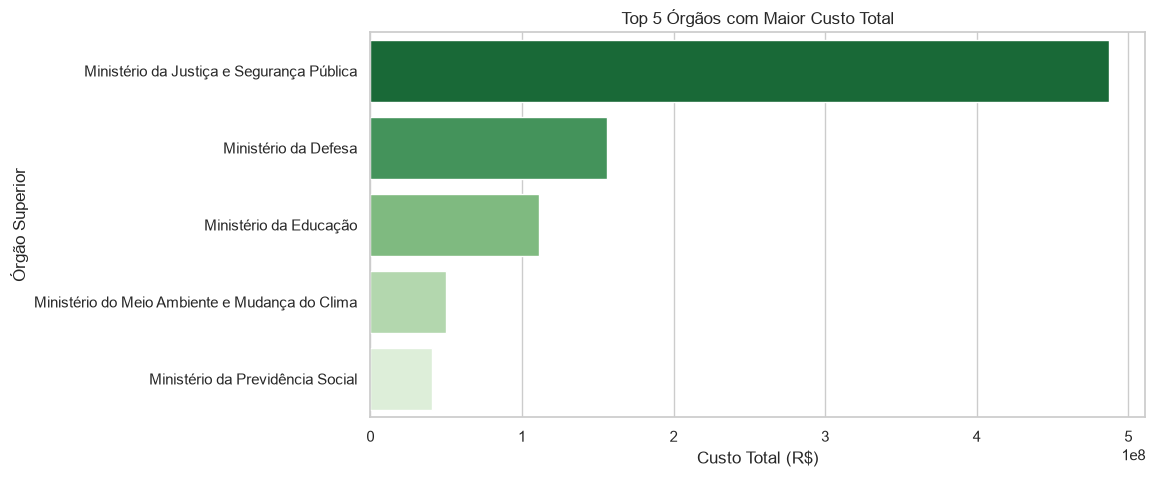

In [ ]:
# [Camada Silver] Pergunta 1: Top 5 Órgãos com Maior Custo Total

query = """
    SELECT nome_orgao_superior, SUM(valor_total) as custo_total 
    FROM silver_viagem 
    GROUP BY nome_orgao_superior ORDER BY custo_total DESC LIMIT 5;
"""
df = pd.read_sql(query, engine)
print("--- TABELA: TOP 5 ÓRGÃOS COM MAIOR CUSTO TOTAL ---")
print(df)

plt.figure(figsize=(10, 5))
# Acrescido hue=y e legend=False evita o aviso de depreciação do seaborn (palette
# sem hue será removido na v0.14) e mantém o mesmo efeito visual de antes.
# order= garante que a ordem decrescente definida no SQL seja preservada no gráfico.
# Paleta trocada para 'Greens_r': cor-tema desta seção (Pergunta 1 - órgãos com
# maior custo), permitindo variar a cor por pergunta de negócio ao longo do notebook.
sns.barplot(
    data=df,
    x='custo_total',
    y='nome_orgao_superior',
    hue='nome_orgao_superior',
    order=df['nome_orgao_superior'],
    palette='Greens_r',
    legend=False
)
plt.title('Top 5 Órgãos com Maior Custo Total')
plt.xlabel('Custo Total (R$)')
plt.ylabel('Órgão Superior')

plt.savefig('imagens/Gráfico_1_orgaos_maior_custo.png', dpi=300, bbox_inches='tight')
plt.show()

--- TABELA: TOP 3 DESTINOS COM MAIOR CUSTO MÉDIO POR VIAGEM (mín. 5 viagens) ---
                     destino  qtd_viagens  custo_medio
0               Sananduva/RS          198    101128.41
1             Monte Negro/RO          152     97346.00
2  Campo Novo de Rondônia/RO          245     95748.59


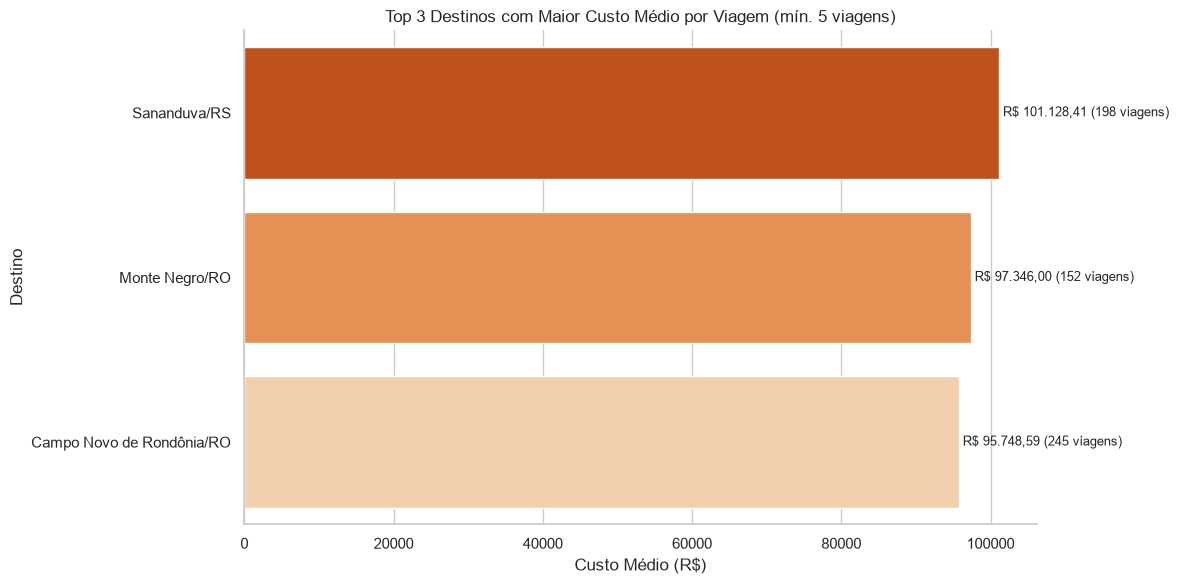

In [34]:
# [Camada Silver] Pergunta 2: Os 3 Destinos com Maior Custo Médio por Viagem

# O campo 'destinos' guarda a lista inteira de cidades da viagem (roteiros
# multi-cidade, separados por vírgula), não um destino único por linha.
# Por isso "explodimos" a string em destinos individuais (string_to_array +
# unnest) antes de agrupar — sem isso, cada viagem multi-cidade vira um
# grupo próprio e gigante, sem nenhum valor analítico.
#
# HAVING COUNT(*) >= 5: alguns registros trazem o campo 'destinos' malformado
# (nomes cortados, ex.: "Brasí" em vez de "Brasília"), efeito de sujeira na
# fonte de dados. Sem uma amostra mínima, um único registro sujo com valor
# alto "vence" o ranking sozinho. Exigir pelo menos 5 viagens por destino
# garante que o Top 3 reflita destinos realmente recorrentes, não outliers.
query = """
    SELECT destino, COUNT(*) AS qtd_viagens, ROUND(AVG(valor_total)::numeric, 2) as custo_medio
    FROM (
        SELECT
            valor_total,
            TRIM(unnest(string_to_array(destinos, ','))) AS destino
        FROM silver_viagem
        WHERE destinos IS NOT NULL AND valor_total IS NOT NULL AND valor_total > 0
    ) destinos_individuais
    WHERE destino != ''
    GROUP BY destino
    HAVING COUNT(*) >= 5
    ORDER BY custo_medio DESC
    LIMIT 3;
"""
df = pd.read_sql(query, engine)
print("--- TABELA: TOP 3 DESTINOS COM MAIOR CUSTO MÉDIO POR VIAGEM (mín. 5 viagens) ---")
print(df)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=df,
    x='custo_medio',
    y='destino',
    hue='destino',
    order=df['destino'],
    palette='Oranges_r',
    legend=False
)
plt.title('Top 3 Destinos com Maior Custo Médio por Viagem (mín. 5 viagens)')
plt.xlabel('Custo Médio (R$)')
plt.ylabel('Destino')

sns.despine()

# Rótulo de valor no fim de cada barra, formatado em R$ (padrão brasileiro),
# incluindo a quantidade de viagens que sustentam a média.
for i, (valor, qtd) in enumerate(zip(df['custo_medio'], df['qtd_viagens'])):
    valor_formatado = f'R$ {valor:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
    ax.text(valor, i, f' {valor_formatado} ({qtd} viagens)', va='center', fontsize=9)

plt.tight_layout()
plt.subplots_adjust(left=0.22)
plt.savefig('imagens/Gráfico_2_destinos_maior_custo_medio.png', dpi=300, bbox_inches='tight')
plt.show()



--- TABELA ATUALIZADA: VIAGEM DE MAIOR DURAÇÃO VÁLIDA ---
             id_viagem                      nome_viajante  \
0  0000000000020793594  Informações protegidas por sigilo   

                            destinos  duracao_dias  valor_total  
0  Informações protegidas por sigilo           379     120650.0  

[Insight do Engenheiro] Viajante: Informações Protegidas Por Sigilo
Destino da Viagem: Informações protegidas por sigilo
Duração: 379 dias | Custo Total: R$ 120,650.00


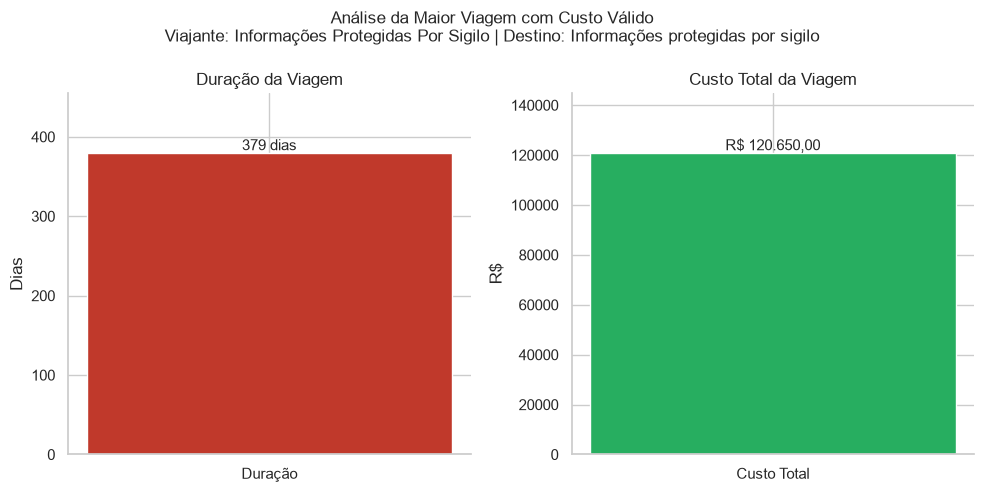

In [35]:
# [Camada Silver] Pergunta 3: Viagem de Maior Duração e seu Custo Total

# Query corrigida pela Engenharia de Dados: busca a maior duração onde o valor_total seja maior que zero.
query = """
    SELECT id_viagem, nome_viajante, destinos, duracao_dias, valor_total 
    FROM silver_viagem 
    WHERE valor_total > 0 AND duracao_dias IS NOT NULL
    ORDER BY duracao_dias DESC LIMIT 1;
"""
df = pd.read_sql(query, engine)

# Configurado o acesso posicional explícito,
# mais robusto do que depender do índice rotulado coincidir com a posição.
nome_cru = df['nome_viajante'].iloc[0]
viajante = str(nome_cru).title().strip()  # Formata para "Nome Sobrenome" legível
destino = df['destinos'].iloc[0]
dias = int(df['duracao_dias'].iloc[0])
custo = float(df['valor_total'].iloc[0])

print("\n--- TABELA ATUALIZADA: VIAGEM DE MAIOR DURAÇÃO VÁLIDA ---")
print(df)
print(f"\n[Insight do Engenheiro] Viajante: {viajante}")
print(f"Destino da Viagem: {destino}")
print(f"Duração: {dias} dias | Custo Total: R$ {custo:,.2f}")

# Configurado eixo duplo (twinx) trocado por dois subplots lado a lado — cada métrica
# com sua própria escala, sem o risco visual de barras sobrepostas na mesma posição
# do eixo X (twinx é adequado para linhas, não para barras comparativas).
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Subplot 1: Duração em dias.
ax1.bar(['Duração'], [dias], color='#C0392B', width=0.4)
ax1.set_ylabel('Dias')
ax1.set_title('Duração da Viagem')
ax1.text(0, dias, f'{dias} dias', ha='center', va='bottom', fontsize=11)
ax1.set_ylim(0, dias * 1.2)
sns.despine(ax=ax1)

# Subplot 2: Custo total em R$.
ax2.bar(['Custo Total'], [custo], color='#27AE60', width=0.4)
ax2.set_ylabel('R$')
ax2.set_title('Custo Total da Viagem')
custo_formatado = f'R$ {custo:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
ax2.text(0, custo, custo_formatado, ha='center', va='bottom', fontsize=11)
ax2.set_ylim(0, custo * 1.2)
sns.despine(ax=ax2)

fig.suptitle(f'Análise da Maior Viagem com Custo Válido\nViajante: {viajante} | Destino: {destino}', fontsize=12)
fig.tight_layout()

plt.savefig('imagens/Gráfico_3_viagem_maior_duracao.png', dpi=300, bbox_inches='tight')
plt.show()


--- TABELA: VALOR MÉDIO POR TIPO DE PAGAMENTO ---
              tipo_pagamento  valor_medio
0                    DIÁRIAS      2078.28
1                   PASSAGEM      1878.34
2  Serviço correlato: seguro       447.51
3                RESTITUIÇÃO       245.70


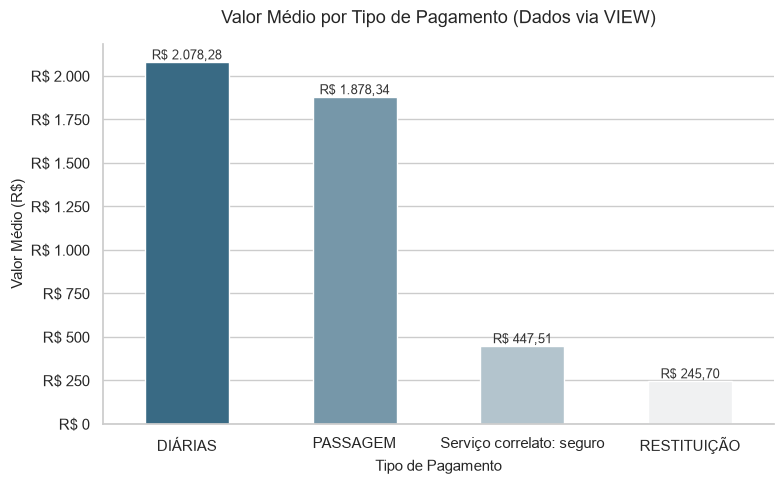

In [36]:
# [Camada Gold - VIEW] Pergunta 4: Tipo de Pagamento com Maior Valor Médio

query = """
    SELECT tipo_pagamento, ROUND(AVG(valor_pagamento)::numeric, 2) as valor_medio 
    FROM gold.vw_financeiro_pagamentos 
    GROUP BY tipo_pagamento ORDER BY valor_medio DESC;
"""
df = pd.read_sql(query, engine)
print("\n--- TABELA: VALOR MÉDIO POR TIPO DE PAGAMENTO ---")
print(df)

# Configurado figsize mais estreito, mais adequado a poucas categorias.
plt.figure(figsize=(8, 5))

paleta_pagamento = sns.light_palette("#2C6E91", n_colors=len(df), reverse=True)

ax = sns.barplot(
    data=df,
    x='tipo_pagamento',
    y='valor_medio',
    hue='tipo_pagamento',
    order=df['tipo_pagamento'],
    palette=paleta_pagamento,
    legend=False,
    width=0.5
)
plt.title('Valor Médio por Tipo de Pagamento (Dados via VIEW)', fontsize=13, pad=15)
plt.xlabel('Tipo de Pagamento', fontsize=11)
plt.ylabel('Valor Médio (R$)', fontsize=11)

# Ajustada formatação do eixo Y como moeda brasileira.
ax.yaxis.set_major_formatter(lambda y, pos: f'R$ {y:,.0f}'.replace(',', '.'))

# Remoção das bordas superior e direita.
sns.despine()

# Posto o rótulo de valor no topo de cada barra.
for i, valor in enumerate(df['valor_medio']):
    valor_formatado = f'R$ {valor:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
    ax.text(i, valor, valor_formatado, ha='center', va='bottom', fontsize=9, color='#333333')

plt.tight_layout()
plt.savefig('imagens/Gráfico_4_pagamento_maior_valor_medio.png', dpi=300, bbox_inches='tight')
plt.show()


--- TABELA: MEIO DE TRANSPORTE MAIS USADO NOS TRECHOS ---
   meio_transporte  quantidade_trechos
0  Veículo Oficial            386424.0
1            Aéreo            232666.0
2       Rodoviário             64970.0
3  Veículo Próprio             42846.0
4          Fluvial              8429.0
5      Ferroviário               874.0
6         Marítimo               481.0


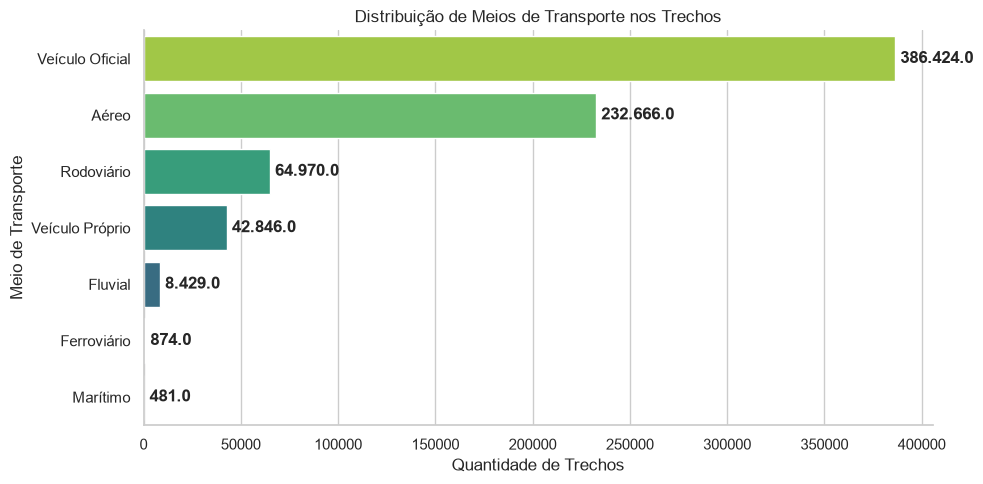

In [37]:
# [Camada Gold - Tabela Agregada] Pergunta 5: Meio de Transporte mais Usado nos Trechos

query = """
    SELECT meio_transporte, SUM(qtd_trechos) as quantidade_trechos 
    FROM gold.fato_viagens_trechos 
    WHERE meio_transporte IS NOT NULL 
      AND meio_transporte NOT IN ('Sem informação', 'Inválido', '')
    GROUP BY meio_transporte 
    ORDER BY quantidade_trechos DESC;
"""
df = pd.read_sql(query, engine)
print("\n--- TABELA: MEIO DE TRANSPORTE MAIS USADO NOS TRECHOS ---")
print(df)

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=df,
    x='quantidade_trechos',
    y='meio_transporte',
    hue='meio_transporte',
    order=df['meio_transporte'],
    palette='viridis_r',
    legend=False
)
plt.title('Distribuição de Meios de Transporte nos Trechos')
plt.xlabel('Quantidade de Trechos')
plt.ylabel('Meio de Transporte')

sns.despine()

# Adicionados rótulos de texto com a contagem exata no final de cada barra
# (formatado no padrão brasileiro de milhar: ponto em vez de vírgula).
for index, value in enumerate(df['quantidade_trechos']):
    valor_formatado = f'{value:,}'.replace(',', '.')
    plt.text(value, index, f' {valor_formatado}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('imagens/Gráfico_5_meio_transporte_mais_usado.png', dpi=300, bbox_inches='tight')
plt.show()


--- TABELA: TOP 10 UFs DE DESTINO COM MAIS TRECHOS ---
           destino_uf  total_trechos
0           São Paulo        82722.0
1    Distrito Federal        79962.0
2        Minas Gerais        50965.0
3      Rio de Janeiro        44197.0
4              Paraná        42603.0
5                Pará        40044.0
6   Rio Grande do Sul        38684.0
7  Mato Grosso do Sul        30516.0
8               Bahia        28375.0
9          Pernambuco        28372.0

[Resposta] UF de destino com mais trechos: São Paulo (82.722.0 trechos)


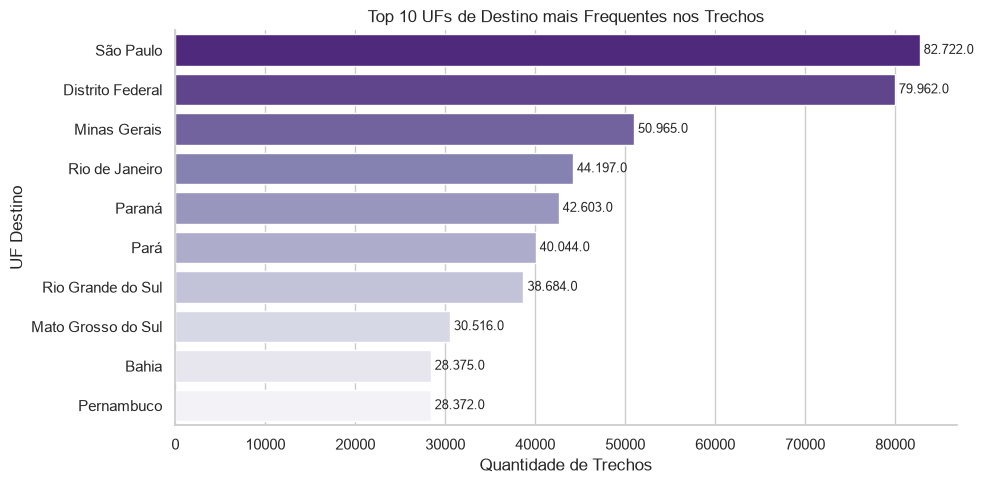

In [38]:
# [Camada Gold - Tabela Agregada] Pergunta 6: UF de Destino mais Frequente nos Trechos

query = """
    SELECT destino_uf, SUM(qtd_trechos) as total_trechos 
    FROM gold.fato_viagens_trechos 
    WHERE destino_uf IS NOT NULL AND destino_uf != 'Sem informação'
    GROUP BY destino_uf ORDER BY total_trechos DESC LIMIT 10;
"""
df = pd.read_sql(query, engine)

# Imprime a tabela completa (Top 10), consistente com o que é plotado no
# gráfico, e destaca separadamente a resposta direta da pergunta (a UF nº1).
print("\n--- TABELA: TOP 10 UFs DE DESTINO COM MAIS TRECHOS ---")
print(df)
print(f"\n[Resposta] UF de destino com mais trechos: {df['destino_uf'].iloc[0]} "
      f"({df['total_trechos'].iloc[0]:,} trechos)".replace(',', '.'))

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=df,
    x='total_trechos',
    y='destino_uf',
    hue='destino_uf',
    order=df['destino_uf'],
    palette='Purples_r',
    legend=False
)
plt.title('Top 10 UFs de Destino mais Frequentes nos Trechos')
plt.xlabel('Quantidade de Trechos')
plt.ylabel('UF Destino')

sns.despine()

# Rótulo de valor no fim de cada barra, no padrão brasileiro de milhar.
for i, valor in enumerate(df['total_trechos']):
    valor_formatado = f'{valor:,}'.replace(',', '.')
    ax.text(valor, i, f' {valor_formatado}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('imagens/Gráfico_6_uf_destino_mais_frequente.png', dpi=300, bbox_inches='tight')
plt.show()


--- TABELA: ÓRGÃO PAGADOR QUE MAIS PAGOU NO TOTAL ---
                    nome_orgao_pagador    total_pago
0  Fundo Nacional de Segurança Pública  2.784810e+08
1                             Sigiloso  2.004848e+08
2               Comando da Aeronáutica  8.176914e+07
3  Instituto Nacional do Seguro Social  3.742760e+07
4                  Comando do Exército  3.687264e+07


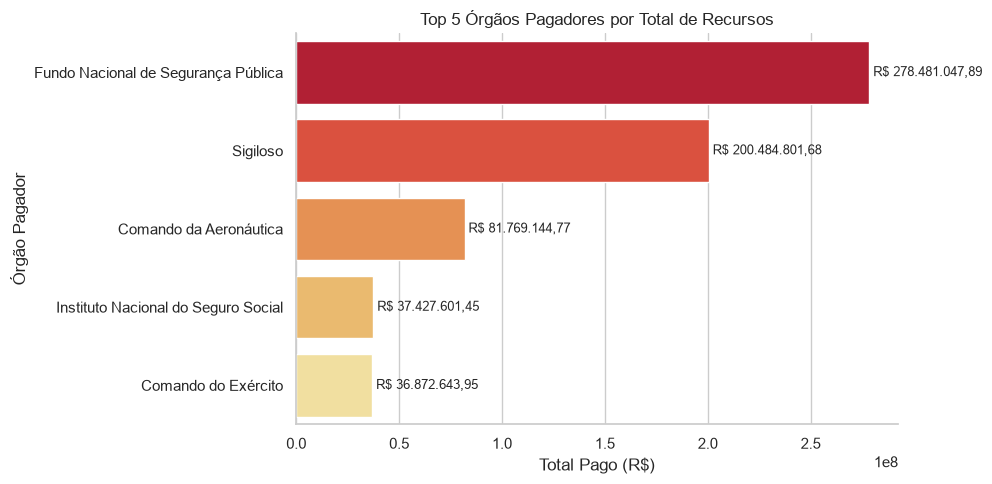

In [39]:
# [Camada Gold - VIEW] Pergunta 7: Órgão Pagador com Maior Total Pago no Período

query = """
    SELECT nome_orgao_pagador, SUM(valor_pagamento) as total_pago 
    FROM gold.vw_financeiro_pagamentos 
    GROUP BY nome_orgao_pagador ORDER BY total_pago DESC LIMIT 5;
"""
df = pd.read_sql(query, engine)
print("\n--- TABELA: ÓRGÃO PAGADOR QUE MAIS PAGOU NO TOTAL ---")
print(df)

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=df,
    x='total_pago',
    y='nome_orgao_pagador',
    hue='nome_orgao_pagador',
    order=df['nome_orgao_pagador'],
    palette='YlOrRd_r',
    legend=False
)
plt.title('Top 5 Órgãos Pagadores por Total de Recursos')
plt.xlabel('Total Pago (R$)')
plt.ylabel('Órgão Pagador')

sns.despine()

# Rótulo de valor no fim de cada barra, formatado em R$ (padrão brasileiro).
for i, valor in enumerate(df['total_pago']):
    valor_formatado = f'R$ {valor:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')
    ax.text(valor, i, f' {valor_formatado}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('imagens/Gráfico_7_orgao_pagador_maior_valor.png', dpi=300, bbox_inches='tight')
plt.show()